# Cleaning — ECB Rate Shock & SME Failures

## Objective
Assign sectors to treatment/control by bank-credit dependence, assemble the panel, and build the **annual non-overlapping** sample used for estimation. The raw series is a 12-month rolling cumulative; sampled monthly it is heavily autocorrelated and its early post-hike values still contain pre-hike months. Taking each December (= calendar-year total) gives one clean, non-overlapping observation per year.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, str(Path().resolve().parent))
from src.data_loader import load_failures, load_sector_debt_structure, SECTOR_LABELS
from src import cleaning

Path('../outputs').mkdir(exist_ok=True)
Path('../data/processed').mkdir(exist_ok=True)
print('Environment ready')

Environment ready


## 1. Treatment group: bank-credit dependence
Each sector is scored by the FIBEN bank-debt share (ratio BE), averaged over 2018-2021, then split at the median into treatment (high dependence) and control.

,label,bank_dependence,treated
AZ,Agriculture,80.6,True
I,Accommodation & food,71.7,True
PS,"Education, health, personal services",68.8,True
MN,Business services,61.3,True
G,Trade & auto repair,60.0,True
FZ,Construction,59.4,False
BE,Industry,38.4,False
JZ,Information & communication,31.7,False
H,Transport & storage,27.7,False


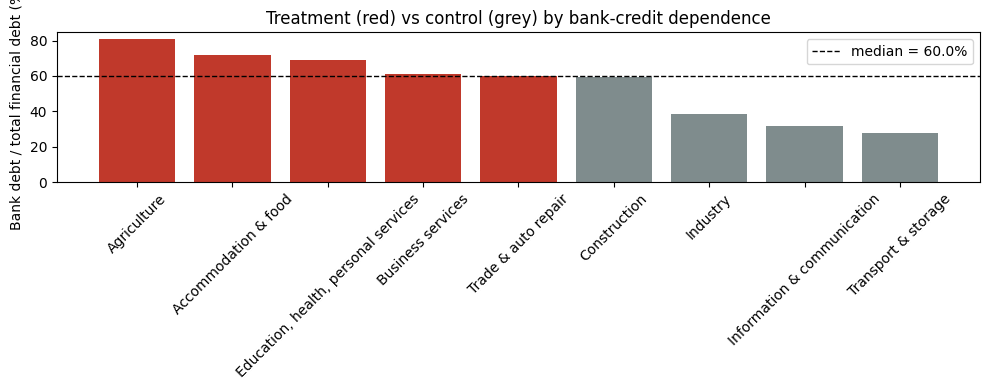

In [2]:
debt = load_sector_debt_structure()
dependence = cleaning.bank_credit_dependence(debt)
treatment = cleaning.assign_treatment(dependence)
treatment['label'] = [SECTOR_LABELS[s] for s in treatment.index]
display(treatment[['label', 'bank_dependence', 'treated']].round(1))

colors = treatment['treated'].map({True: '#c0392b', False: '#7f8c8d'})
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(treatment['label'], treatment['bank_dependence'], color=colors)
ax.axhline(treatment['bank_dependence'].median(), color='black', ls='--', lw=1,
           label=f"median = {treatment['bank_dependence'].median():.1f}%")
ax.set_ylabel('Bank debt / total financial debt (%)')
ax.set_title('Treatment (red) vs control (grey) by bank-credit dependence')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/treatment_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Monthly series (visualisation) and parallel-trends view
The monthly 12-month-cumulative series is used only for visualisation. The grey band is the COVID/PGE window.

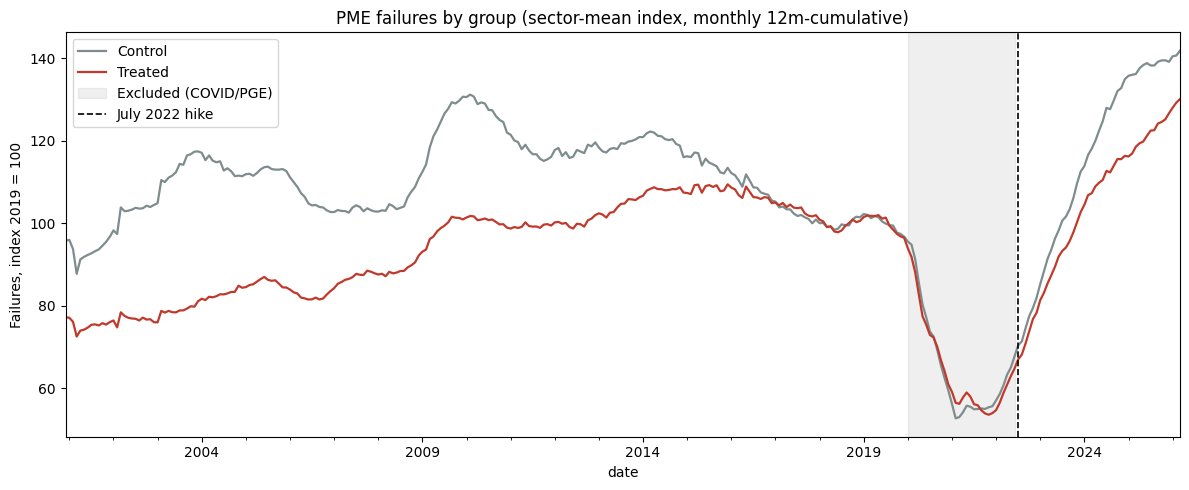

In [3]:
failures = load_failures()
panel = cleaning.build_panel(failures, treatment)

base = panel[panel['date'].dt.year == 2019].groupby('sector')['failures'].mean()
panel['idx'] = panel['failures'] / panel['sector'].map(base) * 100
grp = (panel.groupby([panel['date'], 'treated'])['idx'].mean()
       .unstack().rename(columns={1: 'Treated', 0: 'Control'}))

fig, ax = plt.subplots(figsize=(12, 5))
grp.plot(ax=ax, color={'Treated': '#c0392b', 'Control': '#7f8c8d'}, linewidth=1.6)
ax.axvspan(cleaning.COVID_START, cleaning.COVID_END, alpha=0.12, color='gray',
           label='Excluded (COVID/PGE)')
ax.axvline(cleaning.ECB_FIRST_HIKE, color='black', ls='--', lw=1.2, label='July 2022 hike')
ax.set_ylabel('Failures, index 2019 = 100')
ax.set_title('PME failures by group (sector-mean index, monthly 12m-cumulative)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/panel_windows.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Annual non-overlapping panel (used for estimation)
Each December = that calendar year's total failures. Baseline years 2015-2019, post years 2023 onward; 2020-2022 dropped (COVID/PGE and the 2022 transition year, whose December cumulative still straddles the July-2022 hike).

In [4]:
annual = cleaning.annualize(panel, 'sector')
sample = annual[annual['in_sample']]
print('annual rows (in sample):', len(sample))
print('years:', sorted(sample['year'].unique()))
print('sectors:', sample['sector'].nunique())
display(sample.pivot(index='year', columns='sector', values='failures'))

treatment.to_csv('../data/processed/treatment.csv')
annual.to_csv('../data/processed/sector_panel_annual.csv', index=False)
print('treatment.csv and sector_panel_annual.csv written')

annual rows (in sample): 72
years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2023), np.int32(2024), np.int32(2025)]
sectors: 9


sector,AZ,BE,FZ,G,H,I,JZ,MN,PS
year,,,,,,,,,
2015,1360.0,4557.0,15857.0,13731.0,1750.0,8427.0,1427.0,6505.0,5811.0
2016,1444.0,4121.0,13702.0,12490.0,1743.0,7749.0,1410.0,6305.0,5530.0
2017,1528.0,3871.0,12139.0,12042.0,1830.0,7310.0,1381.0,5768.0,5436.0
2018,1419.0,3912.0,11888.0,11578.0,2047.0,7303.0,1290.0,6155.0,5358.0
2019,1414.0,3426.0,11089.0,11132.0,2093.0,6840.0,1277.0,5810.0,5138.0
2023,1307.0,3924.0,11830.0,12046.0,2285.0,7800.0,1717.0,6524.0,5444.0
2024,1444.0,4234.0,14827.0,13807.0,2990.0,8556.0,1997.0,7914.0,5980.0
2025,1670.0,4396.0,14387.0,13833.0,3193.0,9332.0,2081.0,8563.0,6738.0


treatment.csv and sector_panel_annual.csv written
